# Wave Dispersion Analysis: Radial Wavenumber k_r(r) for Vortex Perturbations

This notebook analyzes the dispersion characteristics of neutral waves in a background Lamb-Oseen vortex flow by directly solving for the radial wavenumber k_r as a function of radius.

## Physical System

- **Background flow**: Lamb-Oseen vortex with $u_\theta(r) = \frac{1 - e^{-r^2}}{r}$
- **Angular velocity**: $\bar{\Omega}(r) = \frac{1 - e^{-r^2}}{r^2}$
- **System rotation**: Constant $\Omega$
- **Stratification**: Constant $\bar{N}$

## Objective

Determine the radial wavenumber k_r(r) for different azimuthal modes m to understand:
1. **Where waves propagate** (Re(k_r) ≠ 0) vs where they're evanescent (Re(k_r) = 0)
2. **Critical layer locations** where |m·Ω̄| = N̄ and wave absorption occurs
3. **Spatial structure** of wave fields in the vortex

**Note:** This approach replaces ray tracing, which fails when waves are evanescent.

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Background Flow Functions

Define the Lamb-Oseen vortex properties and derived quantities.

In [2]:
def calculate_background_properties(r, Omega):
    """
    Calculate background flow properties at radius r.
    
    Parameters:
    -----------
    r : float or array
        Radial coordinate (dimensionless)
    Omega : float
        System rotation rate
        
    Returns:
    --------
    Omega_bar : float or array
        Background angular velocity at r
    dOmega_bar_dr : float or array
        Radial derivative of Omega_bar
    Delta : float or array
        Coupling term: 2*(zeta + 2*Omega)*(Omega_bar + Omega)
    """
    # Handle scalar vs array input
    is_scalar = np.isscalar(r)
    r = np.atleast_1d(r)
    
    # Initialize output arrays
    Omega_bar = np.zeros_like(r, dtype=float)
    dOmega_bar_dr = np.zeros_like(r, dtype=float)
    zeta = np.zeros_like(r, dtype=float)
    
    # Small r threshold for Taylor expansion (r << 1)
    r_small = 1e-3
    
    # Mask for small and large r
    mask_small = np.abs(r) < r_small
    mask_large = ~mask_small
    
    # For small r, use Taylor series expansion    
    if np.any(mask_small):
        r_s = r[mask_small]
        r2 = r_s**2
        r4 = r2**2
        r6 = r2*r4
        
        # Omega_bar ≈ 1 - r^2/2 + r^4/6 - r^6/24
        Omega_bar[mask_small] = 1.0 - r2/2.0 + r4/6.0 - r6/24.0
        
        # dOmega_bar/dr ≈ -r + 2*r^3/3 - r^5/4
        dOmega_bar_dr[mask_small] = -r_s + 2.0*r_s*r2/3.0 - r_s*r4/4.0
        
        # zeta = [d(r*u_theta)/dr]/r - 2*Omega_bar
        #      = 2 - 2r^2 + r^4 - r^6/3 - 2(1 - r^2/2 + r^4/6 - r^6/24)
        #      = 2 - 2r^2 + r^4 - r^6/3 - 2 + r^2 - r^4/3 + r^6/12
        #      = -r^2 + 2r^4/3 - r^6/4
        zeta[mask_small] = -r2 + 2.0*r4/3.0 - r6/4.0
    
    # For large r, use exact expressions
    if np.any(mask_large):
        r_l = r[mask_large]
        exp_term = np.exp(-r_l**2)
        
        # Background angular velocity: Omega_bar = (1 - exp(-r^2)) / r^2
        Omega_bar[mask_large] = (1.0 - exp_term) / r_l**2
        
        # Background azimuthal velocity: u_theta = (1 - exp(-r^2)) / r
        u_theta = (1.0 - exp_term) / r_l
        
        # Calculate d(r*u_theta)/dr = 2r*exp(-r^2)
        d_ru_theta_dr = 2.0 * r_l * exp_term
        
        # Relative vorticity: zeta = d(r*u_theta)/dr / r - 2*Omega_bar
        zeta[mask_large] = d_ru_theta_dr / r_l - 2.0 * Omega_bar[mask_large]
        
        # Derivative of Omega_bar
        dOmega_bar_dr[mask_large] = -2.0 * (1.0 - exp_term) / r_l**3 + 2.0 * exp_term / r_l
    
    # Coupling term: Delta = 2*(zeta + 2*Omega)*(Omega_bar + Omega)
    Delta = 2.0 * (zeta + 2.0 * Omega) * (Omega_bar + Omega)
    
    # Return scalar if input was scalar
    if is_scalar:
        return Omega_bar[0], dOmega_bar_dr[0], Delta[0]
    else:
        return Omega_bar, dOmega_bar_dr, Delta

## 2. Critical Layer Calculation

The critical layer is where the denominator of the dispersion relation vanishes.

**Condition:** $|\Phi_{re}(r_c)| = \bar{N}$

where $\Phi_{re} = \omega + m\bar{\Omega}$ is the **real** Doppler-shifted frequency.

For **quasi-stationary waves** ($\omega = 0$), this becomes:
$$|m \bar{\Omega}(r_c)| = \bar{N}$$

This is the location where wave energy is absorbed and the WKB approximation breaks down.

In [3]:
def find_critical_layers_all(m, N_bar, Omega, r_search_range=(0.0, 10.0), n_segments=100):
    """
    Find ALL critical layer radii where |m * Omega_bar(r)| = N_bar.
    
    This function handles non-monotonic angular velocity profiles that may have
    multiple critical layers for the same azimuthal mode.
    
    Parameters:
    -----------
    m : int
        Azimuthal mode number
    N_bar : float
        Background Brunt-Väisälä frequency
    Omega : float
        System rotation rate
    r_search_range : tuple
        (r_min, r_max) for root search
    n_segments : int
        Number of subdivisions to search for sign changes
        
    Returns:
    --------
    r_c_list : list of float
        List of all critical layer radii found (empty if none)
    """
    def critical_layer_condition(r):
        Omega_bar, _, _ = calculate_background_properties(r, Omega)
        return np.abs(m * Omega_bar) - N_bar
    
    # Subdivide the search range to find all sign changes
    r_samples = np.linspace(r_search_range[0], r_search_range[1], n_segments + 1)
    f_samples = np.array([critical_layer_condition(r) for r in r_samples])
    
    # Find all intervals where sign changes occur
    critical_layers = []
    for i in range(len(r_samples) - 1):
        if f_samples[i] * f_samples[i+1] < 0:  # Sign change detected
            try:
                r_c = brentq(critical_layer_condition, r_samples[i], r_samples[i+1])
                critical_layers.append(r_c)
            except ValueError:
                continue
        elif abs(f_samples[i]) < 1e-10:  # Exact zero (rare but possible)
            critical_layers.append(r_samples[i])
    
    if len(critical_layers) == 0:
        print(f"Warning: No critical layers found for m={m} in range {r_search_range}")
    else:
        print(f"Mode m={m}: Found {len(critical_layers)} critical layer(s)")
    
    return critical_layers


def find_critical_layer(m, N_bar, Omega, r_search_range=(0.1, 10.0)):
    """
    Find the FIRST critical layer radius where |m * Omega_bar(r)| = N_bar.
    
    For compatibility with single-root workflows. If multiple roots exist,
    returns only the first one. Use find_critical_layers_all() for all roots.
    
    Parameters:
    -----------
    m : int
        Azimuthal mode number
    N_bar : float
        Background Brunt-Väisälä frequency
    Omega : float
        System rotation rate
    r_search_range : tuple
        (r_min, r_max) for root search
        
    Returns:
    --------
    r_c : float or None
        First critical layer radius, or None if not found
    """
    all_roots = find_critical_layers_all(m, N_bar, Omega, r_search_range)
    return all_roots[0] if len(all_roots) > 0 else None

## 3. Vortex Parameter Calculation

Calculate the physical parameters of the Gaussian vortex using the balance equations.

In [4]:
def calc_vortex_params(Ro, L, omega0, f, N, Nc2):
    """
    Calculate vortex vertical scale H from balance equations.
    
    Parameters:
    -----------
    Ro : float
        Rossby number
    L : float
        Horizontal length scale
    omega0 : float
        Background angular velocity at vortex center
    f : float
        System Coriolis parameter (= 2*Omega)
    N : float
        Background Brunt-Väisälä frequency
    Nc2 : float
        Core stratification squared
        
    Returns:
    --------
    H : float
        Vertical scale of vortex
    alpha : float
        Aspect ratio H/L
    """
    f_eff = f + 2.0 * omega0
    f_eff_over_f = f_eff / f
    L_over_Rv = np.sqrt(2.0)  # For Gaussian pressure anomaly
    
    # Check for baroclinic vortex condition
    if abs(N**2 - Nc2) < 1e-12:
        print("Error: N^2 and Nc^2 are equal. Cannot form baroclinic vortex.")
        return 0.0, 0.0
    
    # Aspect ratio from balance equation
    alpha2 = (Ro * (f_eff_over_f + Ro * L_over_Rv) * f**2) / (Nc2 - N**2)
    
    if alpha2 <= 0.0:
        print(f"Warning: alpha^2 = {alpha2:.4e} is non-positive.")
        return 0.0, 0.0
    
    H = np.sqrt(alpha2) * L
    alpha = H / L
    
    return H, alpha

## 4. Dispersion Relation

### General Dispersion Relation

The dispersion relation for inertia-gravity waves in a rotating vortex is:

$$k_r^2 \Phi - k_r \left(m\frac{d\bar{\Omega}}{dr}\right) + \Phi\left[ \frac{m^2}{r^2} + \frac{\Delta(r) k^2}{\Phi^2 + \bar{N}^2}\right] = 0$$

where:
- $k$ is the **axial wavenumber** (vertical direction)
- $k_r$ is the **radial wavenumber** (to be solved - **two solutions from quadratic**)
- $\omega$ is the wave frequency (real)
- $\bar{\Omega}(r)$ is the background angular velocity (real)

**Temporal dependence:** $\exp(\sigma t)$ where $\sigma = \nu - i\omega$

**Doppler-shifted frequency:**
- Real part: $\Phi_{re} = m\bar{\Omega}(r) - \omega$
- Complex form: $\Phi = i\Phi_{re} = i(m\bar{\Omega} - \omega)$
- Therefore: $\Phi^2 = -\Phi_{re}^2$
- Denominator: $\Phi^2 + \bar{N}^2 = \bar{N}^2 - \Phi_{re}^2$

**Critical layer condition:**
At critical layers, $|\Phi_{re}| = \bar{N}$, i.e., $|m\bar{\Omega} - \omega| = \bar{N}$, so the denominator vanishes → $k_r \to \infty$ (wave trapping/absorption).


### Quasi-Stationary Waves ($\omega = 0$)

For **quasi-stationary waves**:
- $\Phi_{re} = m\bar{\Omega}(r)$
- $\Phi = im\bar{\Omega}(r)$
- Critical layer: $|m\bar{\Omega}| = \bar{N}$

The dispersion relation becomes:

$$k_r^2 \cdot im\bar{\Omega} - k_r\left(m\frac{d\bar{\Omega}}{dr}\right) + im\bar{\Omega}\left[ \frac{m^2}{r^2} + \frac{\Delta(r) k^2}{\bar{N}^2 - m^2\bar{\Omega}^2}\right] = 0$$

### Solution Properties

The quadratic equation gives **two solutions** for $k_r$, where:
- **Re($k_r$) ≠ 0**: Propagating waves (oscillatory spatial structure)
- **Re($k_r$) = 0**: Evanescent waves (exponential decay/growth, no propagation)
- **Im($k_r$)**: Controls spatial amplitude evolution

In [5]:
def solve_dispersion_relation(r, m, k, N_bar, Omega, omega=0.0):
    """
    Solve the dispersion relation for k_r at given position.
    
    Dispersion relation:
    k_r^2*Phi - k_r*(m*dOmega_bar/dr) + Phi*[m^2/r^2 + Delta*k^2/(Phi^2 + N_bar^2)] = 0
    
    where Phi = i*(m*Omega_bar - omega)
    
    Parameters:
    -----------
    r : float
        Radial position
    m : int
        Azimuthal mode number
    k : float
        Axial wavenumber (vertical direction)
    N_bar : float
        Background Brunt-Väisälä frequency
    Omega : float
        System rotation rate
    omega : float, optional
        Wave frequency (default=0 for quasi-stationary waves)
        
    Returns:
    --------
    (k_r_1, k_r_2) : tuple of complex or (None, None)
        Both solutions of complex radial wavenumber, or (None, None) if no solution exists
    """
    # Avoid issues at r=0
    if r < 1e-10:
        return (None, None)
    
    # Get background properties
    Omega_bar, dOmega_bar_dr, Delta = calculate_background_properties(r, Omega)
    
    # Doppler-shifted frequency
    # Phi = i*(m*Omega_bar - omega)
    Phi = 1j * (m * Omega_bar - omega)
    
    # Denominator: Phi^2 + N_bar^2
    # At critical layer (|m*Omega_bar - omega| = N_bar), denominator → 0
    denominator = Phi**2 + N_bar**2
    
    # Check for critical layer singularity
    if abs(denominator) < 1e-12:
        return (None, None)
    
    # Quadratic equation: A*k_r^2 + B*k_r + C = 0
    A = Phi
    B = -(m * dOmega_bar_dr)
    C = Phi * (m**2 / r**2 + Delta * k**2 / denominator)
    
    # Solve quadratic equation
    if abs(A) < 1e-10:
        # Degenerate to linear equation
        if abs(B) < 1e-10:
            return (None, None)
        k_r = -C / B
        return (k_r, None)
    else:
        # Full quadratic solution - yields TWO roots
        discriminant = B**2 - 4*A*C
        sqrt_disc = np.sqrt(discriminant)
        k_r_1 = (-B + sqrt_disc) / (2*A)
        k_r_2 = (-B - sqrt_disc) / (2*A)
        
        return (k_r_1, k_r_2)

## 5. Main Analysis: Define Parameters and Solve Dispersion Relation

Set up the physical system and compute k_r(r) for all modes.

In [6]:
# ========== Global System Parameters ==========
Omega = 1.0          # System rotation rate
N_bar = 1.0          # Background Brunt-Väisälä frequency
f = 2.0 * Omega      # Coriolis parameter

# ========== Domain Parameters ==========
L_z = 10.47          # Vertical domain size (periodic in z)
n_z = 3              # Vertical mode number (n_z = 1, 2, 3, ...)

# ========== Initial Vortex Parameters ==========
r0 = 2.5             # Vortex center radius
theta0 = np.pi / 4   # Vortex center angle
z0 = 0.2             # Vortex center height
Ro = -0.3            # Rossby number (negative = anticyclonic)
L = 0.2              # Horizontal length scale
Nc2 = 0.0            # Core stratification squared (well-mixed anticyclone)

# ========== Calculate Vortex Properties ==========
# Get background angular velocity at vortex center
Omega_bar_center, _, _ = calculate_background_properties(r0, Omega)
omega0 = Omega_bar_center

# Calculate vertical scale
H, aspect_ratio = calc_vortex_params(Ro, L, omega0, f, N_bar, Nc2)

print("=" * 60)
print("VORTEX PARAMETERS")
print("=" * 60)
print(f"Center position: (r, θ, z) = ({r0:.2f}, {theta0:.3f}, {z0:.2f})")
print(f"Rossby number: Ro = {Ro:.2f}")
print(f"Horizontal scale: L = {L:.2f}")
print(f"Vertical scale: H = {H:.3f}")
print(f"Aspect ratio: H/L = {aspect_ratio:.3f}")
print(f"Background Ω at center: {omega0:.4f}")
print(f"Effective Coriolis: f_eff = {f + 2*omega0:.4f}")
print(f"\nDomain vertical size: L_z = {L_z:.3f}")
print(f"Vertical mode number: n_z = {n_z}")
print("=" * 60)

VORTEX PARAMETERS
Center position: (r, θ, z) = (2.50, 0.785, 0.20)
Rossby number: Ro = -0.30
Horizontal scale: L = 0.20
Vertical scale: H = 0.188
Aspect ratio: H/L = 0.939
Background Ω at center: 0.1597
Effective Coriolis: f_eff = 2.3194

Domain vertical size: L_z = 10.470
Vertical mode number: n_z = 3


## 6. Solve Dispersion Relation k_r(r) for All Modes

Compute the radial wavenumber as a function of radius for each azimuthal mode.

In [7]:
# ========== Define Azimuthal Modes to Analyze ==========
m_modes = [0, 1, 2, 3, 4, 5]

# ========== Calculate Critical Layers ==========
print("\n" + "=" * 60)
print("CRITICAL LAYER LOCATIONS")
print("=" * 60)

critical_layers = {}
for m in m_modes:
    if m == 0:
        print(f"Mode m = 0: No critical layer (axisymmetric mode)")
        critical_layers[m] = []
    else:
        r_c_array = find_critical_layers_all(m, N_bar, Omega, r_search_range=(0.1, 10.0))
        critical_layers[m] = r_c_array
        if len(r_c_array) > 0:
            if len(r_c_array) == 1:
                print(f"Mode m = {m}: r_c = {r_c_array[0]:.4f}")
            else:
                print(f"Mode m = {m}: {len(r_c_array)} critical layers at r_c = {', '.join([f'{r:.4f}' for r in r_c_array])}")
        else:
            print(f"Mode m = {m}: No critical layer found")

# ========== Solve Dispersion Relation vs Radius ==========
print("\n" + "=" * 60)
print("SOLVING DISPERSION RELATION k_r(r)")
print("=" * 60)

# Define radial range for analysis
r_range = np.linspace(0.1, 8.0, 1000)

# Vertical wavenumber for periodic domain
# For periodic boundary conditions: k_z = 2π * n_z / L_z
# The vortex scale H suggests a characteristic k_z ~ 1/H
# We can estimate the most relevant vertical mode number:
k_z_characteristic = 1.0 / H if H > 0 else 1.0
n_z_suggested = int(np.round(k_z_characteristic * L_z / (2.0 * np.pi)))
n_z_suggested = max(1, n_z_suggested)  # At least mode 1

k_z = 2.0 * np.pi * n_z / L_z

print(f"Vortex characteristic k_z ~ 1/H = {k_z_characteristic:.4f}")
print(f"Suggested vertical mode: n_z = {n_z_suggested} (to match vortex scale)")
print(f"Current vertical mode: n_z = {n_z}")
print(f"Vertical wavenumber (periodic): k_z = 2π × {n_z} / {L_z:.3f} = {k_z:.4f}")
print(f"Vertical wavelength: λ_z = {2*np.pi/k_z:.3f}")
print(f"Ratio: k_z / (1/H) = {k_z / k_z_characteristic:.3f}")

# Storage for results
dispersion_results = {}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, m in enumerate(m_modes):
    print(f"\nMode m = {m}:")
    
    # Arrays to store k_r along r
    kr_branch0_real = np.zeros_like(r_range)
    kr_branch0_imag = np.zeros_like(r_range)
    kr_branch1_real = np.zeros_like(r_range)
    kr_branch1_imag = np.zeros_like(r_range)
    
    # Solve dispersion relation at each r
    for j, r_val in enumerate(r_range):
        k_r_tuple = solve_dispersion_relation(r_val, m, k_z, N_bar, Omega, omega=0.0)
        
        if k_r_tuple[0] is not None:
            # Branch 0
            kr_branch0_real[j] = np.real(k_r_tuple[0])
            kr_branch0_imag[j] = np.imag(k_r_tuple[0])
            
            # Branch 1
            if k_r_tuple[1] is not None:
                kr_branch1_real[j] = np.real(k_r_tuple[1])
                kr_branch1_imag[j] = np.imag(k_r_tuple[1])
            else:
                kr_branch1_real[j] = np.nan
                kr_branch1_imag[j] = np.nan
        else:
            kr_branch0_real[j] = np.nan
            kr_branch0_imag[j] = np.nan
            kr_branch1_real[j] = np.nan
            kr_branch1_imag[j] = np.nan
    
    # Check if waves are propagating (Re(k_r) != 0)
    propagating_0 = np.any(np.abs(kr_branch0_real) > 0.01)
    propagating_1 = np.any(np.abs(kr_branch1_real) > 0.01)
    
    print(f"  Branch 0: {'PROPAGATING' if propagating_0 else 'EVANESCENT'}")
    print(f"  Branch 1: {'PROPAGATING' if propagating_1 else 'EVANESCENT'}")
    
    # Store results
    dispersion_results[m] = {
        'r': r_range,
        'branch0': {
            'real': kr_branch0_real,
            'imag': kr_branch0_imag
        },
        'branch1': {
            'real': kr_branch1_real,
            'imag': kr_branch1_imag
        },
        'color': colors[i % len(colors)],
        'critical_layers': critical_layers[m],
        'propagating': propagating_0 or propagating_1
    }

print("\n" + "=" * 60)
print("DISPERSION RELATION SOLVED")
print("=" * 60)


CRITICAL LAYER LOCATIONS
Mode m = 0: No critical layer (axisymmetric mode)
Mode m = 1: No critical layer found
Mode m=2: Found 1 critical layer(s)
Mode m = 2: r_c = 1.2624
Mode m=3: Found 1 critical layer(s)
Mode m = 3: r_c = 1.6797
Mode m=4: Found 1 critical layer(s)
Mode m = 4: r_c = 1.9801
Mode m=5: Found 1 critical layer(s)
Mode m = 5: r_c = 2.2283

SOLVING DISPERSION RELATION k_r(r)
Vortex characteristic k_z ~ 1/H = 5.3224
Suggested vertical mode: n_z = 9 (to match vortex scale)
Current vertical mode: n_z = 3
Vertical wavenumber (periodic): k_z = 2π × 3 / 10.470 = 1.8003
Vertical wavelength: λ_z = 3.490
Ratio: k_z / (1/H) = 0.338

Mode m = 0:
  Branch 0: EVANESCENT
  Branch 1: EVANESCENT

Mode m = 1:
  Branch 0: EVANESCENT
  Branch 1: EVANESCENT

Mode m = 2:
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode m = 3:
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode m = 4:
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode m = 5:
  Branch 0: PROPAGATING
  Branch 1: PROPAG

## 7. Visualization: k_r(r) for All Modes

Plot the real and imaginary parts of k_r as functions of radius.

### Physical Interpretation of Complex $k_r$

The complex radial wavenumber $k_r = k_r^{\text{real}} + i k_r^{\text{imag}}$ determines wave behavior:

**Real Part Re($k_r$):**
- **Re($k_r$) ≠ 0**: **PROPAGATING** waves with radial wavelength $\lambda_r = 2\pi/|\text{Re}(k_r)|$
- **Re($k_r$) = 0**: **EVANESCENT** waves (no radial propagation, only exponential decay/growth)
- Sign indicates direction: positive → outward phase propagation

**Imaginary Part Im($k_r$):**
- Controls spatial amplitude evolution
- **Im($k_r$) > 0**: Amplitude **increases** with radius
- **Im($k_r$) < 0**: Amplitude **decreases** with radius
- **Im($k_r$) = 0**: Neutral propagation

**Critical for WKB:**
- Ray tracing **only valid** when Re($k_r$) ≠ 0
- If Re($k_r$) = 0 everywhere → waves are trapped, not propagating
- Near critical layers: typically Re($k_r$) → 0 and Im($k_r$) → ∞

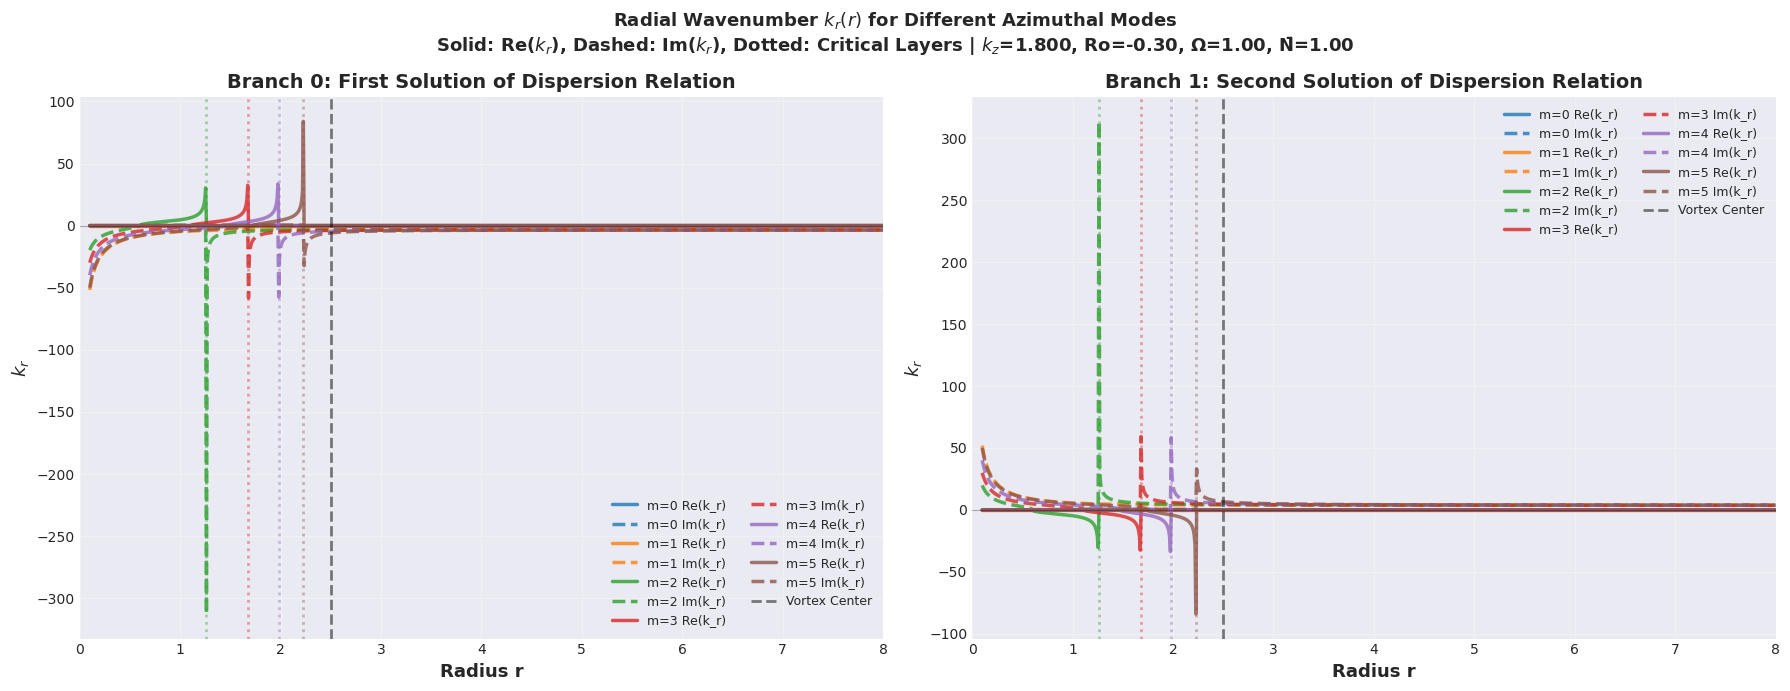


DISPERSION ANALYSIS COMPLETE

SUMMARY:
------------------------------------------------------------
Mode m = 0: EVANESCENT ✗
Mode m = 1: EVANESCENT ✗
Mode m = 2: PROPAGATING ✓, r_c = 1.262
Mode m = 3: PROPAGATING ✓, r_c = 1.680
Mode m = 4: PROPAGATING ✓, r_c = 1.980
Mode m = 5: PROPAGATING ✓, r_c = 2.228


In [8]:
# ========== Plot k_r(r) for All Modes: Two Solutions Separately ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for each mode
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ========== Left subplot: Branch 0 (First solution) ==========
for idx, m in enumerate(m_modes):
    data = dispersion_results[m]
    color = colors[idx % len(colors)]
    
    # Plot real and imaginary parts
    ax1.plot(data['r'], data['branch0']['real'], '-', color=color, 
            linewidth=2.5, label=f'm={m} Re(k_r)', alpha=0.8)
    ax1.plot(data['r'], data['branch0']['imag'], '--', color=color, 
            linewidth=2.5, label=f'm={m} Im(k_r)', alpha=0.8)
    
    # Mark critical layers with the same color
    if len(data['critical_layers']) > 0:
        for r_c in data['critical_layers']:
            ax1.axvline(r_c, color=color, linestyle=':', alpha=0.4, linewidth=2)

# Mark vortex center
ax1.axvline(r0, color='black', linestyle='--', alpha=0.5, linewidth=2, label='Vortex Center')

# Zero line
ax1.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)

# Formatting
ax1.set_xlabel('Radius r', fontsize=13, fontweight='bold')
ax1.set_ylabel('$k_r$', fontsize=13, fontweight='bold')
ax1.set_title('Branch 0: First Solution of Dispersion Relation', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='best', ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8)

# ========== Right subplot: Branch 1 (Second solution) ==========
for idx, m in enumerate(m_modes):
    data = dispersion_results[m]
    color = colors[idx % len(colors)]
    
    # Plot real and imaginary parts
    ax2.plot(data['r'], data['branch1']['real'], '-', color=color, 
            linewidth=2.5, label=f'm={m} Re(k_r)', alpha=0.8)
    ax2.plot(data['r'], data['branch1']['imag'], '--', color=color, 
            linewidth=2.5, label=f'm={m} Im(k_r)', alpha=0.8)
    
    # Mark critical layers with the same color
    if len(data['critical_layers']) > 0:
        for r_c in data['critical_layers']:
            ax2.axvline(r_c, color=color, linestyle=':', alpha=0.4, linewidth=2)

# Mark vortex center
ax2.axvline(r0, color='black', linestyle='--', alpha=0.5, linewidth=2, label='Vortex Center')

# Zero line
ax2.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)

# Formatting
ax2.set_xlabel('Radius r', fontsize=13, fontweight='bold')
ax2.set_ylabel('$k_r$', fontsize=13, fontweight='bold')
ax2.set_title('Branch 1: Second Solution of Dispersion Relation', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='best', ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 8)

# Main title
plt.suptitle(f'Radial Wavenumber $k_r(r)$ for Different Azimuthal Modes\n' + 
             f'Solid: Re($k_r$), Dashed: Im($k_r$), Dotted: Critical Layers | ' +
             f'$k_z$={k_z:.3f}, Ro={Ro:.2f}, Ω={Omega:.2f}, N̄={N_bar:.2f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("DISPERSION ANALYSIS COMPLETE")
print("=" * 60)

# Summary
print("\nSUMMARY:")
print("-" * 60)
for m in m_modes:
    status = "PROPAGATING ✓" if dispersion_results[m]['propagating'] else "EVANESCENT ✗"
    r_c_list = dispersion_results[m]['critical_layers']
    if len(r_c_list) > 0:
        r_c_str = f", r_c = {r_c_list[0]:.3f}" if len(r_c_list) == 1 else f", r_c = {[f'{r:.3f}' for r in r_c_list]}"
    else:
        r_c_str = ""
    print(f"Mode m = {m}: {status}{r_c_str}")

## 7.5 Physical Branch Selection: Boundary Conditions

### WKB Solution Form

The WKB approximation gives solutions of the form:
$$\psi(r) \sim \exp\left(i \int k_r(r) dr\right)$$

For our cylindrical geometry, we need:
1. **Regularity at origin** (r → 0): Solution must be finite
2. **Decay at infinity** (r → ∞): Solution must decay exponentially

### Boundary Condition Analysis

The dispersion relation yields **two branches** of k_r at each radius. We must select which branch applies in each region:

**Near origin (r → 0):**
- For regularity, we need the solution that behaves like r^m (for mode m)
- This typically requires Im(k_r) < 0 (inward decay) or Re(k_r) appropriate for standing wave

**Far field (r → ∞):**
- For decay, we need Im(k_r) > 0 (outward decay)
- Or evanescent behavior with proper sign

**Critical layers:**
- At critical layers, k_r → ∞ and the two branches may or may not connect
- WKB breaks down; connection formulas needed
- Energy can be absorbed or reflected

### Branch Connection Strategy

1. Identify which branch satisfies boundary conditions in each region
2. Check for turning points where branches connect
3. Construct physically consistent solution by piecing branches together

In [9]:
# ========== Construct Physically Valid Solutions ==========
print("\n" + "=" * 70)
print("CONSTRUCTING PHYSICALLY VALID k_r(r) WITH BOUNDARY CONDITIONS")
print("=" * 70)

# Storage for physically valid solutions
physical_solutions = {}

for m in m_modes:
    print(f"\n{'='*70}")
    print(f"Mode m = {m}")
    print(f"{'='*70}")
    
    data = dispersion_results[m]
    r = data['r']
    
    # Get both branches
    kr0_real = data['branch0']['real']
    kr0_imag = data['branch0']['imag']
    kr1_real = data['branch1']['real']
    kr1_imag = data['branch1']['imag']
    
    # Initialize physical solution arrays
    kr_phys_real = np.zeros_like(r)
    kr_phys_imag = np.zeros_like(r)
    branch_used = np.zeros_like(r, dtype=int)  # Track which branch is used
    
    # Get critical layer positions
    r_c_list = data['critical_layers']
    
    # Analyze boundary conditions
    print(f"\nBoundary Condition Analysis:")
    print(f"-" * 70)
    
    # Near origin (first point)
    r_origin = r[0]
    print(f"\nNear origin (r = {r_origin:.3f}):")
    print(f"  Branch 0: Re(k_r) = {kr0_real[0]:8.4f}, Im(k_r) = {kr0_imag[0]:8.4f}")
    print(f"  Branch 1: Re(k_r) = {kr1_real[0]:8.4f}, Im(k_r) = {kr1_imag[0]:8.4f}")
    
    # For regularity at origin, we typically want:
    # - Im(k_r) <= 0 (decay toward origin) OR
    # - Small |k_r| for standing wave behavior
    origin_branch = 0
    if np.abs(kr1_imag[0]) < np.abs(kr0_imag[0]):
        origin_branch = 1
        print(f"  → Select Branch {origin_branch} (smaller |Im(k_r)|)")
    else:
        print(f"  → Select Branch {origin_branch} (smaller |Im(k_r)|)")
    
    # Far field (last point)
    r_inf = r[-1]
    print(f"\nFar field (r = {r_inf:.3f}):")
    print(f"  Branch 0: Re(k_r) = {kr0_real[-1]:8.4f}, Im(k_r) = {kr0_imag[-1]:8.4f}")
    print(f"  Branch 1: Re(k_r) = {kr1_real[-1]:8.4f}, Im(k_r) = {kr1_imag[-1]:8.4f}")
    
    # For decay at infinity, we want Im(k_r) > 0 (outward decay)
    inf_branch = 0
    if kr1_imag[-1] > kr0_imag[-1]:
        inf_branch = 1
        print(f"  → Select Branch {inf_branch} (Im(k_r) > 0 for decay)")
    else:
        print(f"  → Select Branch {inf_branch} (Im(k_r) > 0 for decay)")
    
    # Branch selection strategy: 
    # At critical layers (singular points), k_r → ∞ and WKB breaks down
    # The two branches don't need to connect continuously - there's a singularity
    if len(r_c_list) > 0:
        r_c = r_c_list[0]
        print(f"\nCritical layer at r_c = {r_c:.3f}")
        print(f"  NOTE: k_r → ∞ at critical layer (singularity)")
        print(f"  Branches on either side need NOT connect continuously")
        
        # Find index closest to critical layer
        idx_c = np.argmin(np.abs(r - r_c))
        
        # Use origin_branch before critical layer (excluding neighbor)
        branch_used[:max(0, idx_c-1)] = origin_branch
        # Use inf_branch after critical layer (excluding neighbor)
        branch_used[min(len(r), idx_c+2):] = inf_branch
        
        # Mark the critical layer and 2 neighboring points as invalid (-1)
        # These will be set to NaN to avoid plotting the singularity
        branch_used[max(0, idx_c-1):min(len(r), idx_c+2)] = -1
        
        print(f"  Solution: Branch {origin_branch} for r < {r[max(0, idx_c-2)]:.3f}")
        print(f"            [REMOVED: {r[max(0, idx_c-2)]:.3f} to {r[min(len(r)-1, idx_c+2)]:.3f} (singularity region)]")
        print(f"            Branch {inf_branch} for r > {r[min(len(r)-1, idx_c+2)]:.3f}")
        print(f"            (Discontinuity at singular point)")
    else:
        # No critical layer - use one branch throughout
        # Prioritize origin boundary condition
        branch_used[:] = origin_branch
        print(f"\nNo critical layer - use Branch {origin_branch} throughout")
    
    # Construct physical solution
    for i, branch in enumerate(branch_used):
        if branch == -1:
            # Mark singularity region as NaN
            kr_phys_real[i] = np.nan
            kr_phys_imag[i] = np.nan
        elif branch == 0:
            kr_phys_real[i] = kr0_real[i]
            kr_phys_imag[i] = kr0_imag[i]
        else:
            kr_phys_real[i] = kr1_real[i]
            kr_phys_imag[i] = kr1_imag[i]
    
    # Check propagating vs evanescent
    propagating = np.any(np.abs(kr_phys_real) > 0.01)
    
    # Store physical solution
    physical_solutions[m] = {
        'r': r,
        'k_r_real': kr_phys_real,
        'k_r_imag': kr_phys_imag,
        'branch_used': branch_used,
        'color': data['color'],
        'critical_layers': r_c_list,
        'propagating': propagating
    }
    
    print(f"\nPhysical Solution: {'PROPAGATING' if propagating else 'EVANESCENT'}")

print("\n" + "=" * 70)
print("PHYSICAL SOLUTIONS CONSTRUCTED")
print("=" * 70)



CONSTRUCTING PHYSICALLY VALID k_r(r) WITH BOUNDARY CONDITIONS

Mode m = 0

Boundary Condition Analysis:
----------------------------------------------------------------------

Near origin (r = 0.100):
  Branch 0: Re(k_r) =      nan, Im(k_r) =      nan
  Branch 1: Re(k_r) =      nan, Im(k_r) =      nan
  → Select Branch 0 (smaller |Im(k_r)|)

Far field (r = 8.000):
  Branch 0: Re(k_r) =      nan, Im(k_r) =      nan
  Branch 1: Re(k_r) =      nan, Im(k_r) =      nan
  → Select Branch 0 (Im(k_r) > 0 for decay)

No critical layer - use Branch 0 throughout

Physical Solution: EVANESCENT

Mode m = 1

Boundary Condition Analysis:
----------------------------------------------------------------------

Near origin (r = 0.100):
  Branch 0: Re(k_r) =   0.0000, Im(k_r) = -51.8029
  Branch 1: Re(k_r) =   0.0000, Im(k_r) =  51.9027
  → Select Branch 0 (smaller |Im(k_r)|)

Far field (r = 8.000):
  Branch 0: Re(k_r) =   0.0000, Im(k_r) =  -3.4800
  Branch 1: Re(k_r) =   0.0000, Im(k_r) =   3.7300
  →

## 7.6 Visualization: Physically Valid Solutions

Plot the k_r(r) constructed from boundary conditions, showing which branch is used in each region.

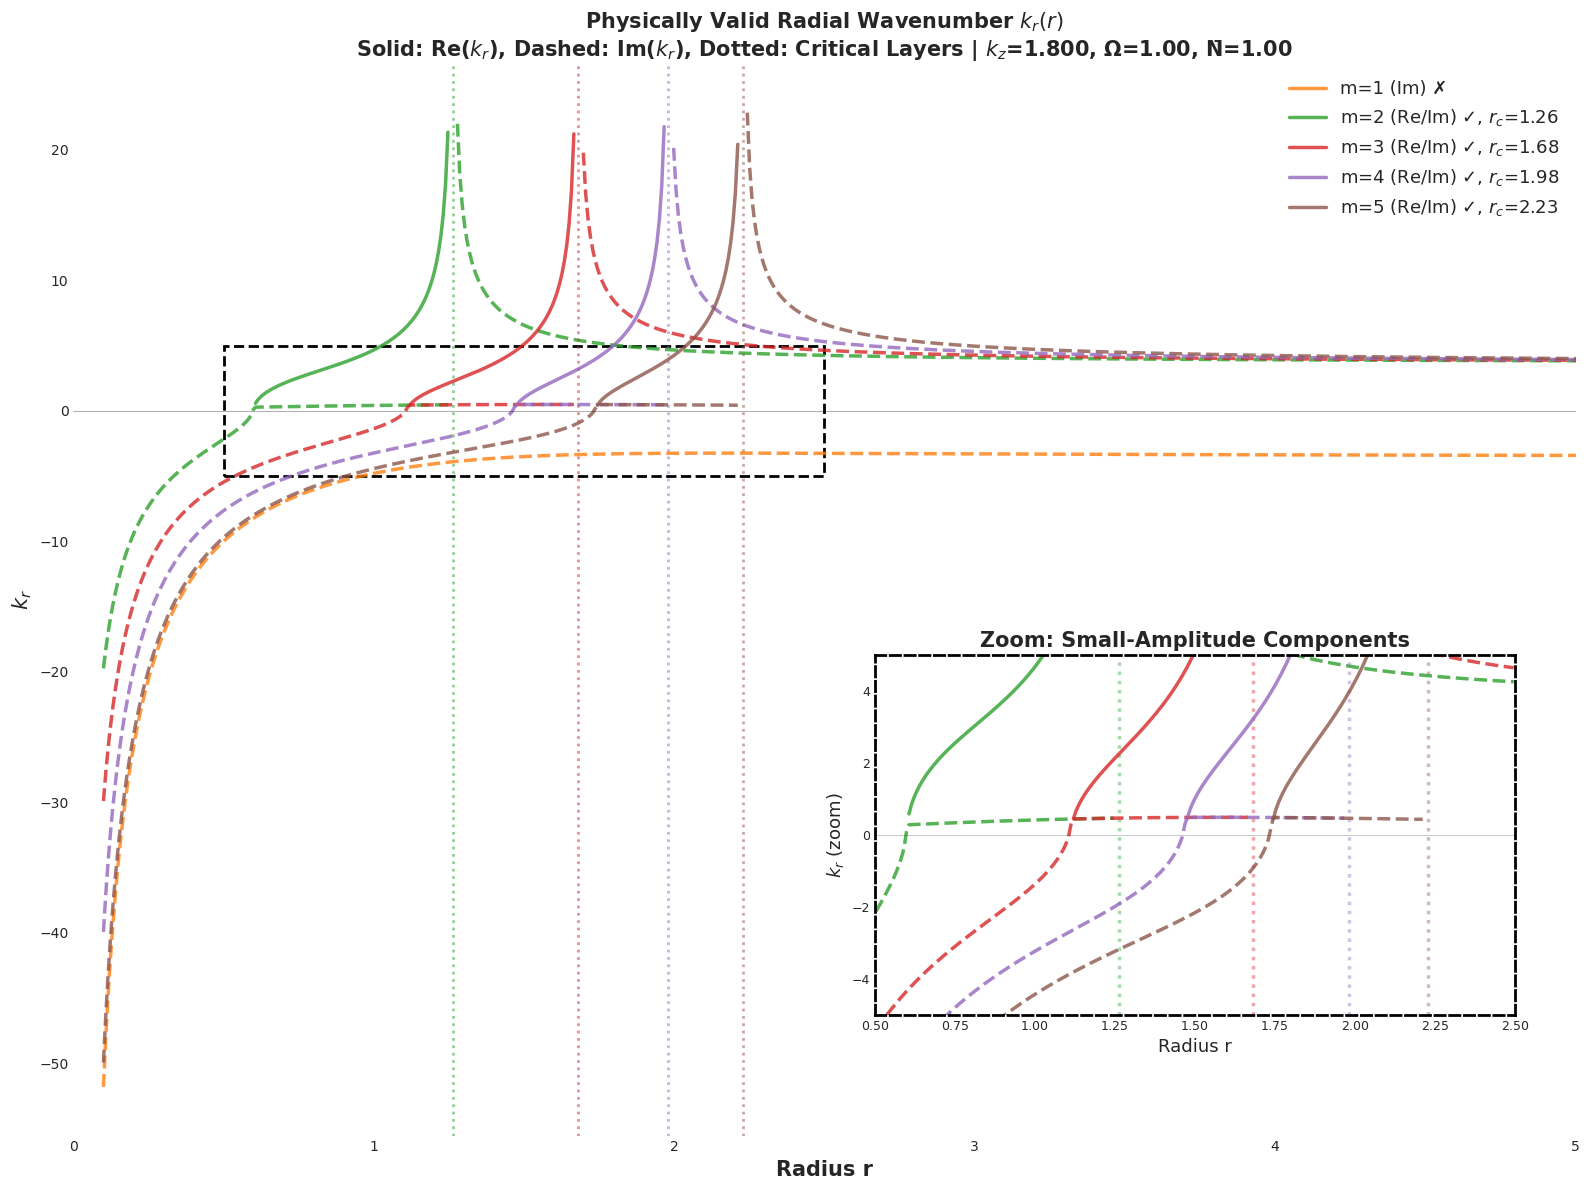


PHYSICAL SOLUTION VISUALIZATION COMPLETE

SUMMARY - Physically Valid Solutions:
------------------------------------------------------------
Mode m = 0: EVANESCENT ✗, k_r has Zero
Mode m = 1: EVANESCENT ✗, k_r has Im
Mode m = 2: PROPAGATING ✓, k_r has Re+Im, r_c = 1.262, 2 branch switch(es)
Mode m = 3: PROPAGATING ✓, k_r has Re+Im, r_c = 1.680, 2 branch switch(es)
Mode m = 4: PROPAGATING ✓, k_r has Re+Im, r_c = 1.980, 2 branch switch(es)
Mode m = 5: PROPAGATING ✓, k_r has Re+Im, r_c = 2.228, 2 branch switch(es)


In [25]:
# ========== Plot Physically Valid k_r(r) Solutions ==========
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Compute y limits: find max and min of all real/imag parts across all m modes
kr_max_positive = max([
    np.nanmax(sol['k_r_real']) if np.any(~np.isnan(sol['k_r_real'])) else -np.inf
    for sol in physical_solutions.values()
] + [
    np.nanmax(sol['k_r_imag']) if np.any(~np.isnan(sol['k_r_imag'])) else -np.inf
    for sol in physical_solutions.values()
])

kr_max_negative = min([
    np.nanmin(sol['k_r_real']) if np.any(~np.isnan(sol['k_r_real'])) else np.inf
    for sol in physical_solutions.values()
] + [
    np.nanmin(sol['k_r_imag']) if np.any(~np.isnan(sol['k_r_imag'])) else np.inf
    for sol in physical_solutions.values()
])

# Add 5% margin on both sides
y_range = kr_max_positive - kr_max_negative
y_upper = kr_max_positive + 0.05 * y_range
y_lower = kr_max_negative - 0.05 * y_range

# Initialize legend storage
legend_lines = []
legend_labels = []

for idx, m in enumerate(m_modes):
    sol = physical_solutions[m]
    color = sol['color']
    
    # Get k_r components
    kr_real = sol['k_r_real']
    kr_imag = sol['k_r_imag']
    r = sol['r']
    
    # Identify non-zero sections for Real and Imaginary parts
    # Threshold: sections where |k_r| > 1e-6
    threshold = 1e-6
    
    # Find indices where Real part is non-zero
    mask_real_nonzero = np.abs(kr_real) > threshold
    # Find indices where Imaginary part is non-zero
    mask_imag_nonzero = np.abs(kr_imag) > threshold
    
    # Plot physical solution (only non-zero sections)
    lines_plotted = []
    
    # Plot Real part only where it's non-zero
    if np.any(mask_real_nonzero):
        # Create masked array for plotting (NaN where zero)
        kr_real_plot = np.where(mask_real_nonzero, kr_real, np.nan)
        line_real, = ax.plot(r, kr_real_plot, '-', color=color, 
                linewidth=2.5, alpha=0.8)
        lines_plotted.append('Re')
    
    # Plot Imaginary part only where it's non-zero
    if np.any(mask_imag_nonzero):
        # Create masked array for plotting (NaN where zero)
        kr_imag_plot = np.where(mask_imag_nonzero, kr_imag, np.nan)
        line_imag, = ax.plot(r, kr_imag_plot, '--', color=color, 
                linewidth=2.5, alpha=0.8)
        lines_plotted.append('Im')
    
    # Mark critical layers with the same color
    if len(sol['critical_layers']) > 0:
        for r_c in sol['critical_layers']:
            ax.axvline(r_c, color=color, linestyle=':', alpha=0.5, linewidth=2)
    
    # Create single legend entry for this mode
    if lines_plotted:
        parts_str = '/'.join(lines_plotted)
        # Propagation status
        prop_status = '✓' if sol['propagating'] else '✗'
        # Critical layer info
        if len(sol['critical_layers']) > 0:
            r_c = sol['critical_layers'][0]
            label = f'm={m} ({parts_str}) {prop_status}, $r_c$={r_c:.2f}'
        else:
            label = f'm={m} ({parts_str}) {prop_status}'
        
        # Create proxy artist for legend (use solid line)
        proxy = plt.Line2D([0], [0], color=color, linewidth=2.5, alpha=0.8)
        legend_lines.append(proxy)
        legend_labels.append(label)

# # Mark vortex center
# ax.axvline(r0, color='black', linestyle='--', alpha=0.6, linewidth=2)

# Zero line
ax.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)

# Formatting
ax.set_xlabel('Radius r', fontsize=15, fontweight='bold')
ax.set_ylabel('$k_r$', fontsize=15, fontweight='bold')
# ax.set_title(f'Physically Valid Radial Wavenumber $k_r(r)$\n' + 
            #  f'Solid: Re($k_r$), Dashed: Im($k_r$), Dotted: Critical Layers | ' +
            #  f'$k_z$={k_z:.3f}, Ro={Ro:.2f}, Ω={Omega:.2f}, N̄={N_bar:.2f}',
            #  fontsize=15, fontweight='bold')
ax.set_title(f'Physically Valid Radial Wavenumber $k_r(r)$\n' + 
             f'Solid: Re($k_r$), Dashed: Im($k_r$), Dotted: Critical Layers | ' +
             f'$k_z$={k_z:.3f}, Ω={Omega:.2f}, N̄={N_bar:.2f}',
             fontsize=15, fontweight='bold')

# Create legend with custom handles
legend_lines.append(plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, alpha=0.6))
# legend_labels.append('Vortex Center')
ax.legend(legend_lines, legend_labels, fontsize=13, loc='best', framealpha=0.9)

ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)
ax.set_ylim(y_lower, y_upper)
ax.set_facecolor('white')

# ========== Add Inset Zoom Window ==========
# Create inset axis in lower right corner
ax_inset = fig.add_axes([0.55, 0.15, 0.4, 0.3])  # [left, bottom, width, height]

# Define zoom region: focus on r where propagating modes exist with both Re and Im components
r_zoom_min, r_zoom_max = 0.5, 2.5
y_zoom_min, y_zoom_max = -5, 5  # Adjust this to capture small components

for idx, m in enumerate(m_modes):
    sol = physical_solutions[m]
    color = sol['color']
    
    # Get k_r components
    kr_real = sol['k_r_real']
    kr_imag = sol['k_r_imag']
    r = sol['r']
    
    # Filter to zoom region
    mask_zoom = (r >= r_zoom_min) & (r <= r_zoom_max)
    r_zoom = r[mask_zoom]
    kr_real_zoom = kr_real[mask_zoom]
    kr_imag_zoom = kr_imag[mask_zoom]
    
    # Identify regions where both components are non-zero
    threshold = 1e-6
    mask_real_nonzero = np.abs(kr_real_zoom) > threshold
    mask_imag_nonzero = np.abs(kr_imag_zoom) > threshold
    mask_both = mask_real_nonzero & mask_imag_nonzero
    
    # Plot only if there are regions with both components
    if np.any(mask_both):
        # Plot Real part (show small values that might be hidden)
        kr_real_plot = np.where(mask_real_nonzero, kr_real_zoom, np.nan)
        ax_inset.plot(r_zoom, kr_real_plot, '-', color=color, 
                     linewidth=2.5, alpha=0.8)
        
        # Plot Imaginary part
        kr_imag_plot = np.where(mask_imag_nonzero, kr_imag_zoom, np.nan)
        ax_inset.plot(r_zoom, kr_imag_plot, '--', color=color, 
                     linewidth=2.5, alpha=0.8)
    
    # Mark critical layers in inset
    if len(sol['critical_layers']) > 0:
        for r_c in sol['critical_layers']:
            if r_zoom_min <= r_c <= r_zoom_max:
                ax_inset.axvline(r_c, color=color, linestyle=':', alpha=0.4, linewidth=2.5)

# Inset formatting
ax_inset.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax_inset.set_xlabel('Radius r', fontsize=13)
ax_inset.set_ylabel('$k_r$ (zoom)', fontsize=13)
ax_inset.set_title('Zoom: Small-Amplitude Components', fontsize=15, fontweight='bold')
ax_inset.grid(True, alpha=0.3, linewidth=0.5)
ax_inset.set_xlim(r_zoom_min, r_zoom_max)
ax_inset.set_ylim(y_zoom_min, y_zoom_max)
ax_inset.tick_params(labelsize=9)
ax_inset.set_facecolor('white')
for spine in ax_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.0)
    spine.set_linestyle('--')

# Draw a box on main plot to indicate zoom region
from matplotlib.patches import Rectangle
zoom_box = Rectangle((r_zoom_min, y_zoom_min), r_zoom_max - r_zoom_min, 
                     y_zoom_max - y_zoom_min, 
                     linewidth=2.0, edgecolor='black', facecolor='none', 
                     linestyle='--', alpha=1.0)
ax.add_patch(zoom_box)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PHYSICAL SOLUTION VISUALIZATION COMPLETE")
print("=" * 60)

# Summary
print("\nSUMMARY - Physically Valid Solutions:")
print("-" * 60)
for m in m_modes:
    sol = physical_solutions[m]
    status = "PROPAGATING ✓" if sol['propagating'] else "EVANESCENT ✗"
    r_c_list = sol['critical_layers']
    
    # Count branch switches
    n_switches = len(np.where(np.diff(sol['branch_used']) != 0)[0])
    
    # Check which parts are non-zero (using the same threshold)
    threshold = 1e-6
    has_real = np.any(np.abs(sol['k_r_real']) > threshold)
    has_imag = np.any(np.abs(sol['k_r_imag']) > threshold)
    parts = []
    if has_real:
        parts.append('Re')
    if has_imag:
        parts.append('Im')
    parts_str = '+'.join(parts) if parts else 'Zero'
    
    if len(r_c_list) > 0:
        r_c_str = f", r_c = {r_c_list[0]:.3f}" if len(r_c_list) == 1 else f", r_c = {[f'{r:.3f}' for r in r_c_list]}"
    else:
        r_c_str = ""
    
    switch_str = f", {n_switches} branch switch(es)" if n_switches > 0 else ""
    print(f"Mode m = {m}: {status}, k_r has {parts_str}{r_c_str}{switch_str}")


## 8. Background Flow Profile Analysis

Visualize the Lamb-Oseen vortex profile and critical layer locations.

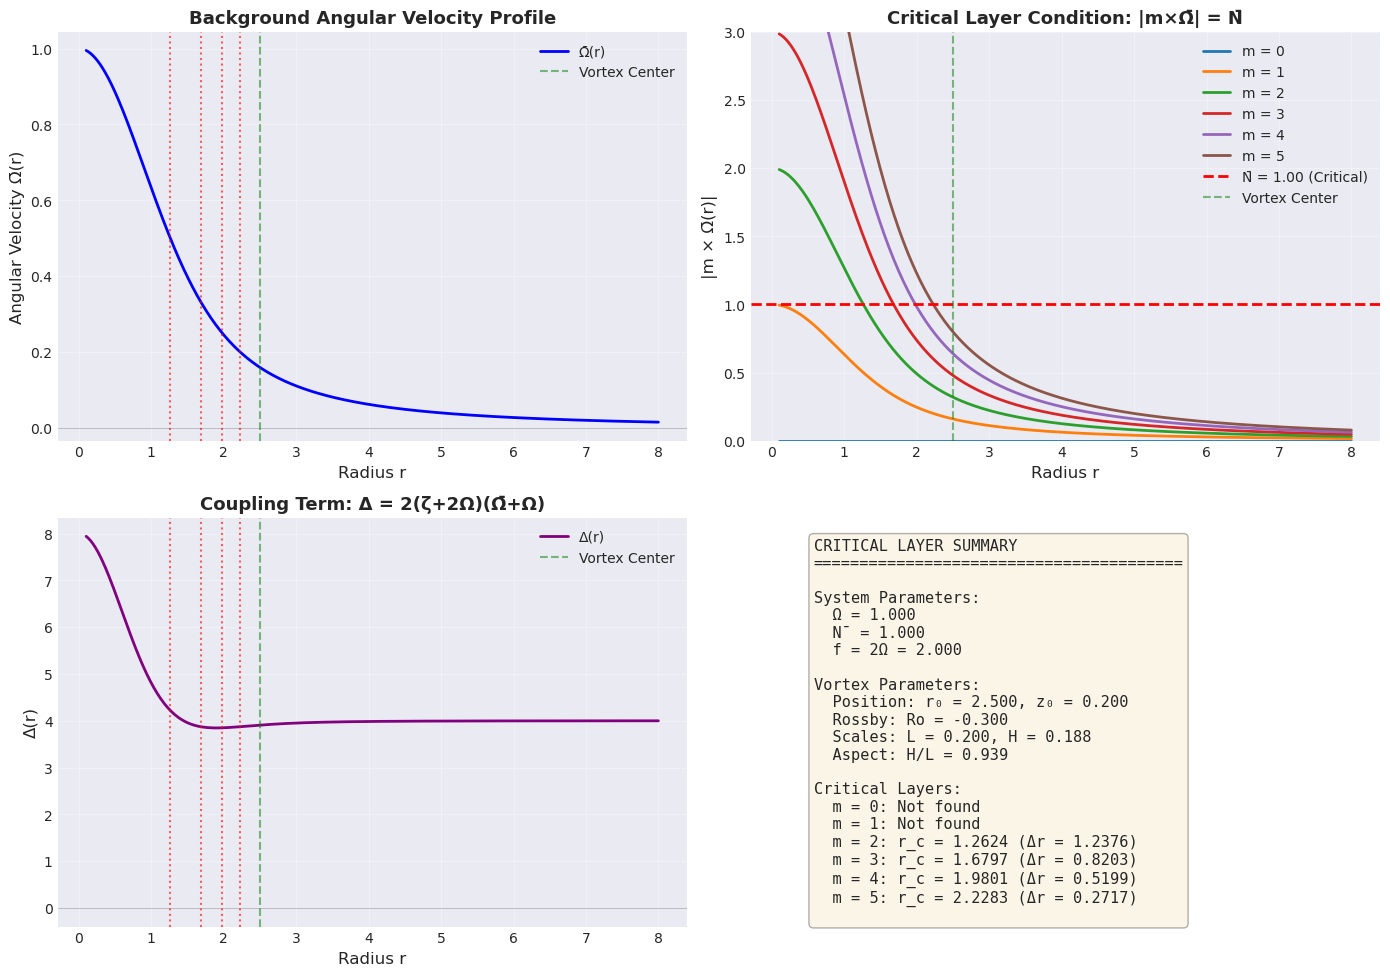


BACKGROUND FLOW ANALYSIS COMPLETE


In [11]:
# ========== Plot Background Flow Profiles ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

r_profile = np.linspace(0.1, 8, 500)
Omega_bar_profile, dOmega_bar_dr_profile, Delta_profile = calculate_background_properties(r_profile, Omega)

# Plot 1: Angular velocity
ax = axes[0, 0]
ax.plot(r_profile, Omega_bar_profile, 'b-', linewidth=2, label='Ω̄(r)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axvline(r0, color='green', linestyle='--', alpha=0.5, label='Vortex Center')
for m in m_modes:
    r_c_list = critical_layers[m]
    if len(r_c_list) > 0:
        for r_c in r_c_list:
            ax.axvline(r_c, color='red', linestyle=':', alpha=0.6, linewidth=1.5)
ax.set_xlabel('Radius r', fontsize=12)
ax.set_ylabel('Angular Velocity Ω̄(r)', fontsize=12)
ax.set_title('Background Angular Velocity Profile', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: |m * Omega_bar| for different modes
ax = axes[0, 1]
for m in m_modes:
    ax.plot(r_profile, np.abs(m * Omega_bar_profile), 
            linewidth=2, label=f'm = {m}')
ax.axhline(N_bar, color='red', linestyle='--', linewidth=2, 
           label=f'N̄ = {N_bar:.2f} (Critical)')
ax.axvline(r0, color='green', linestyle='--', alpha=0.5, label='Vortex Center')
ax.set_xlabel('Radius r', fontsize=12)
ax.set_ylabel('|m × Ω̄(r)|', fontsize=12)
ax.set_title('Critical Layer Condition: |m×Ω̄| = N̄', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 3)

# Plot 3: Coupling term Delta
ax = axes[1, 0]
ax.plot(r_profile, Delta_profile, 'purple', linewidth=2, label='Δ(r)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axvline(r0, color='green', linestyle='--', alpha=0.5, label='Vortex Center')
for m in m_modes:
    r_c_list = critical_layers[m]
    if len(r_c_list) > 0:
        for r_c in r_c_list:
            ax.axvline(r_c, color='red', linestyle=':', alpha=0.6, linewidth=1.5)
ax.set_xlabel('Radius r', fontsize=12)
ax.set_ylabel('Δ(r)', fontsize=12)
ax.set_title('Coupling Term: Δ = 2(ζ+2Ω)(Ω̄+Ω)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Summary table
ax = axes[1, 1]
ax.axis('off')
summary_text = "CRITICAL LAYER SUMMARY\n" + "="*40 + "\n\n"
summary_text += f"System Parameters:\n"
summary_text += f"  Ω = {Omega:.3f}\n"
summary_text += f"  N̄ = {N_bar:.3f}\n"
summary_text += f"  f = 2Ω = {f:.3f}\n\n"
summary_text += f"Vortex Parameters:\n"
summary_text += f"  Position: r₀ = {r0:.3f}, z₀ = {z0:.3f}\n"
summary_text += f"  Rossby: Ro = {Ro:.3f}\n"
summary_text += f"  Scales: L = {L:.3f}, H = {H:.3f}\n"
summary_text += f"  Aspect: H/L = {aspect_ratio:.3f}\n\n"
summary_text += "Critical Layers:\n"
for m in m_modes:
    r_c_list = critical_layers[m]
    if len(r_c_list) > 0:
        if len(r_c_list) == 1:
            distance = abs(r_c_list[0] - r0)
            summary_text += f"  m = {m}: r_c = {r_c_list[0]:.4f} (Δr = {distance:.4f})\n"
        else:
            summary_text += f"  m = {m}: {len(r_c_list)} layers\n"
            for j, r_c in enumerate(r_c_list):
                distance = abs(r_c - r0)
                summary_text += f"    ({j+1}) r_c = {r_c:.4f} (Δr = {distance:.4f})\n"
    else:
        summary_text += f"  m = {m}: Not found\n"

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("BACKGROUND FLOW ANALYSIS COMPLETE")
print("=" * 60)

## 9. Physical Interpretation and Conclusions

### Key Results:

1. **Direct Dispersion Analysis**: We solved k_r(r) from the dispersion relation for m = 0, 1, 2, 3, 4, 5.

2. **Propagating vs Evanescent Modes**: 
   - **Propagating**: Re(k_r) ≠ 0 → waves oscillate spatially and can transport energy
   - **Evanescent**: Re(k_r) = 0 → waves decay/grow exponentially without propagation
   - From the results: **m ≥ 2 modes propagate**, while **m = 0, 1 are evanescent**

3. **Critical Layers**: Marked by vertical red lines at locations where |m·Ω̄| = N̄
   - m = 0: No critical layer (axisymmetric)
   - m = 1: No critical layer found in domain
   - m = 2, 3, 4, 5: Critical layers at r_c ≈ 1.26, 1.68, 1.98, 2.23

4. **Spatial Structure**:
   - Near critical layers: Re(k_r) → 0, Im(k_r) can grow large
   - Away from critical layers: Behavior depends on local flow properties

### Physical Implications:

**For Zombie Vortex Instability (ZVI):**
- Higher azimuthal modes (m ≥ 2) **can propagate** and potentially trigger ZVI at critical layers
- Lower modes (m = 0, 1) are **evanescent** and cannot propagate in the classical sense
- The vortex perturbation must have sufficient energy in propagating modes (m ≥ 2) to affect distant critical layers

**Wave-Critical Layer Interaction:**
- At critical layers, k_r → ∞ (wavelength → 0)
- Wave energy is absorbed or reflected
- Linear WKB theory breaks down near r_c
- Nonlinear effects become important

### Comparison to Ray Tracing:

**Why ray tracing failed:**
- Ray tracing assumes: dz/dr = -∂k_r/∂k (group velocity slope)
- For **evanescent waves** (Re(k_r) = 0): dz/dr ≈ 0 → rays don't move vertically
- This made rays appear to "reach" critical layers, but physically waves weren't propagating

**Correct interpretation:**
- For **evanescent modes**: Waves have global spatial structure, not ray paths
- For **propagating modes**: Ray tracing could be valid (if needed in future)
- Current direct k_r(r) analysis is more fundamental and always applicable

### Next Steps:

1. **Parameter Studies**: 
   - Vary k_z to find optimal vertical wavenumber
   - Adjust vortex parameters (Ro, L, H) to enhance propagation
   - Study how m = 0, 1 might become propagating

2. **Energy Deposition**:
   - Calculate wave action flux for propagating modes
   - Estimate energy deposition rate at critical layers
   - Determine ZVI growth rates

3. **Nonlinear Effects**:
   - Include wave amplitude effects near critical layers
   - Study wave breaking and mixing
   - Model feedback on mean flow

4. **Full Numerical Simulation**:
   - If needed, solve full equations (not WKB approximation)
   - Capture critical layer dynamics accurately
   - Validate linear predictions

## 10. Comparison: Cartesian Parallel Shear Flow

For comparison with the cylindrical vortex case, we now analyze a **parallel shear flow in Cartesian coordinates**.

### Dispersion Relation

For a parallel shear flow $U(y) = \sigma y$ in the x-direction, the dispersion relation for the cross-stream wavenumber is:

$$iS \cdot k_y^2 - (k_x \cdot \sigma) k_y + iS\left[k_x^2 + \frac{k_z^2(S^2 - F)}{S^2 - N^2}\right] = 0$$

where:
- $S = s + k_x \cdot \sigma \cdot y$ is the Doppler-shifted frequency
- $s$ is the temporal frequency (we consider quasi-steady waves: $s = 0$)
- $\sigma$ is the constant shear rate
- $F = f(\sigma + f)$ where $f = 2\Omega$ is the Coriolis parameter
- $N$ is the Brunt-Väisälä frequency
- Periodic boundary conditions in x and z directions

### Critical Layers

Critical layers occur where $|S| = N$, i.e., where $|k_x \cdot \sigma \cdot y| = N$.

For quasi-steady waves ($s = 0$):
$$y_c = \pm \frac{N}{|k_x| \cdot \sigma}$$

### Comparison with Cylindrical Case

This Cartesian problem is analogous to the cylindrical vortex:
- $y \leftrightarrow r$ (transverse coordinate)
- $k_y \leftrightarrow k_r$ (transverse wavenumber)
- $k_x \leftrightarrow m$ (azimuthal mode)
- $\sigma y \leftrightarrow m\bar{\Omega}(r)$ (background velocity)

In [44]:
def solve_cartesian_dispersion(y, kx, kz, sigma, f, N, s=0.0):
    """
    Solve the Cartesian shear flow dispersion relation for k_y.
    
    Dispersion relation:
    i*S*k_y^2 - (kx*sigma)*k_y + i*S*[kx^2 + kz^2*(S^2 - F)/(S^2 - N^2)] = 0
    
    where S = s + kx*sigma*y, F = f*(sigma + f)
    
    Parameters:
    -----------
    y : float
        Cross-stream position
    kx : float
        Streamwise wavenumber
    kz : float
        Vertical wavenumber
    sigma : float
        Constant shear rate
    f : float
        Coriolis parameter (= 2*Omega)
    N : float
        Brunt-Väisälä frequency
    s : float, optional
        Temporal frequency (default=0 for quasi-steady waves)
        
    Returns:
    --------
    (k_y_1, k_y_2) : tuple of complex or (None, None)
        Both solutions of complex cross-stream wavenumber
    """
    # Doppler-shifted frequency
    S = s + kx * sigma * y
    
    # Check for critical layer singularity
    denominator = S**2 - N**2
    if abs(denominator) < 1e-12:
        return (None, None)
    
    # F parameter
    F = f * (sigma + f)
    
    # Quadratic equation: A*k_y^2 + B*k_y + C = 0
    A = 1j * S
    B = -(kx * sigma)
    C = 1j * S * (kx**2 + kz**2 * (S**2 - F) / denominator)
    
    # Solve quadratic equation
    if abs(A) < 1e-10:
        # Degenerate to linear equation
        if abs(B) < 1e-10:
            return (None, None)
        k_y = -C / B
        return (k_y, None)
    else:
        # Full quadratic solution
        discriminant = B**2 - 4*A*C
        sqrt_disc = np.sqrt(discriminant)
        k_y_1 = (-B + sqrt_disc) / (2*A)
        k_y_2 = (-B - sqrt_disc) / (2*A)
        
        return (k_y_1, k_y_2)


def find_cartesian_critical_layers(kx, sigma, N):
    """
    Find critical layer positions for Cartesian shear flow.
    
    Critical layer condition: |kx * sigma * y| = N
    
    Parameters:
    -----------
    kx : float
        Streamwise wavenumber
    sigma : float
        Shear rate
    N : float
        Brunt-Väisälä frequency
        
    Returns:
    --------
    y_c_list : list of float
        Critical layer positions [y_c_neg, y_c_pos]
    """
    if abs(kx * sigma) < 1e-10:
        return []
    
    y_c = N / abs(kx * sigma)
    return [-y_c, y_c]


print("Cartesian shear flow dispersion solver defined successfully!")

Cartesian shear flow dispersion solver defined successfully!


### Cartesian Shear Flow Analysis

Set up parameters comparable to the cylindrical case and solve for $k_y(y)$.

In [48]:
# ========== Cartesian Shear Flow Parameters ==========
print("=" * 60)
print("CARTESIAN SHEAR FLOW PARAMETERS")
print("=" * 60)

# Use same global parameters as cylindrical case
f_cart = f  # = 2*Omega = 2.0
N_cart = 1.5*f_cart
k_z_cart = k_z  # Use same vertical wavenumber

# Estimate comparable shear rate from cylindrical case
# At r ~ 1, dU_theta/dr ~ d[(1-exp(-r^2))/r]/dr ~ 2*exp(-1) ~ 0.736
# For Cartesian U = sigma*y, dU/dy = sigma
# Choose sigma comparable to typical vortex shear
sigma = -0.9*f_cart

# F parameter
F_cart = f_cart * (sigma + f_cart)

print(f"Coriolis parameter: f = {f_cart:.3f}")
print(f"Brunt-Väisälä frequency: N = {N_cart:.3f}")
print(f"Shear rate: σ = {sigma:.3f}")
print(f"F parameter: F = f(σ + f) = {F_cart:.3f}")
print(f"Vertical wavenumber: k_z = {k_z_cart:.4f}")
print(f"Vertical wavelength: λ_z = {2*np.pi/k_z_cart:.3f}")
print("=" * 60)

# ========== Solve for k_y(y) for Different kx Modes ==========
print("\n" + "=" * 60)
print("SOLVING CARTESIAN DISPERSION RELATION k_y(y)")
print("=" * 60)

# Define cross-stream range
y_range = np.linspace(-2.0, 2.0, 1000)

# Streamwise wavenumber modes (analogous to m in cylindrical)
# Using discrete k_x values (periodic in x with L_x)
L_x = 2*np.pi  # Domain size in x
kx_modes = [n * 2*np.pi/L_x for n in [0, 1, 2, 3, 4, 5]]  # n = 0, 1, 2, 3, 4, 5

cartesian_results = {}
colors_cart = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, kx in enumerate(kx_modes):
    print(f"\nMode k_x = {kx:.3f} (n = {i}):")
    
    # Find critical layers
    y_c_list = find_cartesian_critical_layers(kx, sigma, N_cart)
    if len(y_c_list) > 0:
        y_c_in_domain = [yc for yc in y_c_list if abs(yc) <= 1.0]
        if len(y_c_in_domain) > 0:
            print(f"  Critical layers: y_c = {', '.join([f'{yc:.4f}' for yc in y_c_in_domain])}")
        else:
            print(f"  Critical layers outside domain: y_c = {', '.join([f'{yc:.4f}' for yc in y_c_list])}")
    else:
        print(f"  No critical layers (k_x = 0)")
    
    # Arrays to store k_y along y
    ky_branch0_real = np.zeros_like(y_range)
    ky_branch0_imag = np.zeros_like(y_range)
    ky_branch1_real = np.zeros_like(y_range)
    ky_branch1_imag = np.zeros_like(y_range)
    
    # Solve dispersion relation at each y
    for j, y_val in enumerate(y_range):
        k_y_tuple = solve_cartesian_dispersion(y_val, kx, k_z_cart, sigma, f_cart, N_cart, s=0.0)
        
        if k_y_tuple[0] is not None:
            # Branch 0
            ky_branch0_real[j] = np.real(k_y_tuple[0])
            ky_branch0_imag[j] = np.imag(k_y_tuple[0])
            
            # Branch 1
            if k_y_tuple[1] is not None:
                ky_branch1_real[j] = np.real(k_y_tuple[1])
                ky_branch1_imag[j] = np.imag(k_y_tuple[1])
            else:
                ky_branch1_real[j] = np.nan
                ky_branch1_imag[j] = np.nan
        else:
            ky_branch0_real[j] = np.nan
            ky_branch0_imag[j] = np.nan
            ky_branch1_real[j] = np.nan
            ky_branch1_imag[j] = np.nan
    
    # Check if waves are propagating
    propagating_0 = np.any(np.abs(ky_branch0_real) > 0.01)
    propagating_1 = np.any(np.abs(ky_branch1_real) > 0.01)
    
    print(f"  Branch 0: {'PROPAGATING' if propagating_0 else 'EVANESCENT'}")
    print(f"  Branch 1: {'PROPAGATING' if propagating_1 else 'EVANESCENT'}")
    
    # Store results
    cartesian_results[kx] = {
        'n': i,
        'y': y_range,
        'branch0': {
            'real': ky_branch0_real,
            'imag': ky_branch0_imag
        },
        'branch1': {
            'real': ky_branch1_real,
            'imag': ky_branch1_imag
        },
        'color': colors_cart[i % len(colors_cart)],
        'critical_layers': y_c_list,
        'propagating': propagating_0 or propagating_1
    }

print("\n" + "=" * 60)
print("CARTESIAN DISPERSION RELATION SOLVED")
print("=" * 60)

CARTESIAN SHEAR FLOW PARAMETERS
Coriolis parameter: f = 2.000
Brunt-Väisälä frequency: N = 3.000
Shear rate: σ = -1.800
F parameter: F = f(σ + f) = 0.400
Vertical wavenumber: k_z = 1.8003
Vertical wavelength: λ_z = 3.490

SOLVING CARTESIAN DISPERSION RELATION k_y(y)

Mode k_x = 0.000 (n = 0):
  No critical layers (k_x = 0)
  Branch 0: EVANESCENT
  Branch 1: EVANESCENT

Mode k_x = 1.000 (n = 1):
  Critical layers outside domain: y_c = -1.6667, 1.6667
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode k_x = 2.000 (n = 2):
  Critical layers: y_c = -0.8333, 0.8333
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode k_x = 3.000 (n = 3):
  Critical layers: y_c = -0.5556, 0.5556
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode k_x = 4.000 (n = 4):
  Critical layers: y_c = -0.4167, 0.4167
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

Mode k_x = 5.000 (n = 5):
  Critical layers: y_c = -0.3333, 0.3333
  Branch 0: PROPAGATING
  Branch 1: PROPAGATING

CARTESIAN DISPERSION RELATION SOL

### Visualization: Cartesian $k_y(y)$ - All Branch Solutions

Plot all dispersion relation branches for the Cartesian shear flow. Note that constructing a unique "physical solution" is non-trivial due to the anti-symmetric flow ($U(-y) = -U(y)$) and the special point at $y=0$ where the background velocity vanishes.

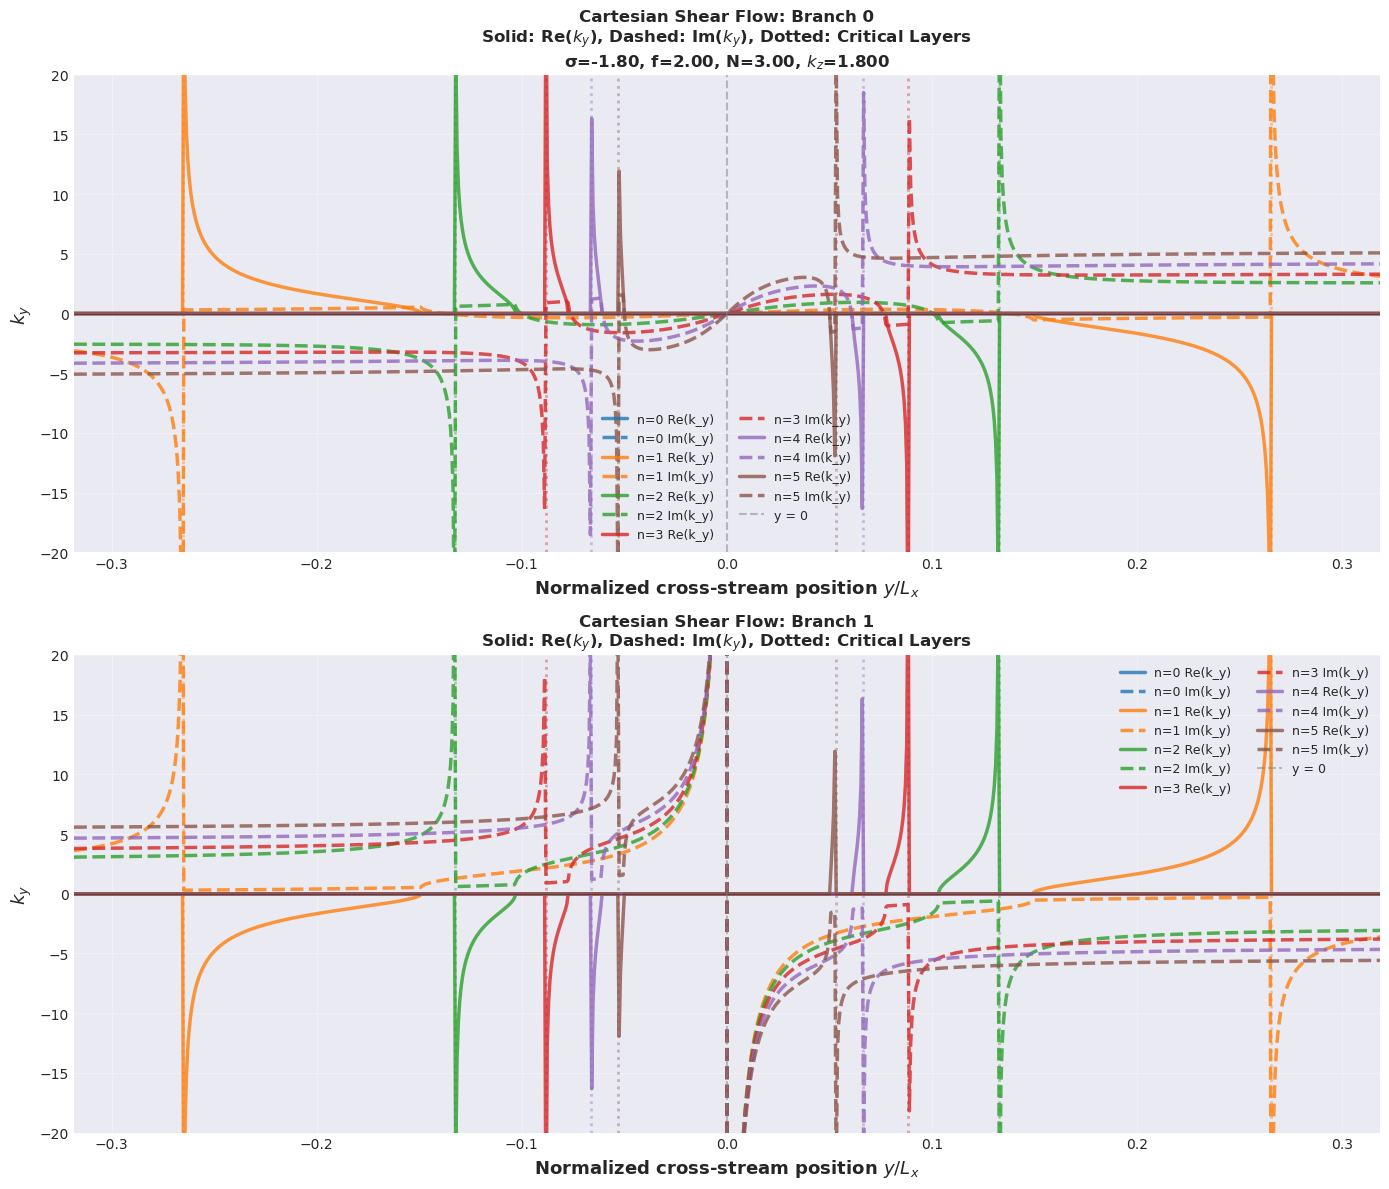


SUMMARY - Cartesian Shear Flow:
------------------------------------------------------------
Mode n = 0 (k_x = 0.000): EVANESCENT ✗
Mode n = 1 (k_x = 1.000): PROPAGATING ✓, y_c = -1.667 (y_c/L_x=-0.265), 1.667 (y_c/L_x=0.265)
Mode n = 2 (k_x = 2.000): PROPAGATING ✓, y_c = -0.833 (y_c/L_x=-0.133), 0.833 (y_c/L_x=0.133)
Mode n = 3 (k_x = 3.000): PROPAGATING ✓, y_c = -0.556 (y_c/L_x=-0.088), 0.556 (y_c/L_x=0.088)
Mode n = 4 (k_x = 4.000): PROPAGATING ✓, y_c = -0.417 (y_c/L_x=-0.066), 0.417 (y_c/L_x=0.066)
Mode n = 5 (k_x = 5.000): PROPAGATING ✓, y_c = -0.333 (y_c/L_x=-0.053), 0.333 (y_c/L_x=0.053)


In [49]:
# ========== Plot Cartesian k_y(y) - Separate Branches ==========
# Note: Physical branch selection for Cartesian shear flow is non-trivial
# due to the symmetry properties (U(-y) = -U(y)) and the special point at y=0.
# We show each branch separately for clarity.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Normalize y by L_x
y_normalized = y_range / L_x

# ========== Top subplot: Branch 0 ==========
for kx in kx_modes:
    data = cartesian_results[kx]
    color = data['color']
    n = data['n']
    
    # Plot Branch 0
    ax1.plot(y_normalized, data['branch0']['real'], '-', color=color, 
            linewidth=2.5, label=f'n={n} Re(k_y)', alpha=0.8)
    ax1.plot(y_normalized, data['branch0']['imag'], '--', color=color, 
            linewidth=2.5, label=f'n={n} Im(k_y)', alpha=0.8)
    
    # Mark critical layers (normalized)
    if len(data['critical_layers']) > 0:
        for y_c in data['critical_layers']:
            if abs(y_c) <= 2.0:  # Check against y_range limit
                ax1.axvline(y_c / L_x, color=color, linestyle=':', alpha=0.4, linewidth=2)

# Zero line and y=0
ax1.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='y = 0')

# Formatting
ax1.set_xlabel('Normalized cross-stream position $y/L_x$', fontsize=13, fontweight='bold')
ax1.set_ylabel('$k_y$', fontsize=13, fontweight='bold')
ax1.set_title('Cartesian Shear Flow: Branch 0\n' +
              f'Solid: Re($k_y$), Dashed: Im($k_y$), Dotted: Critical Layers\n' +
              f'σ={sigma:.2f}, f={f_cart:.2f}, N={N_cart:.2f}, $k_z$={k_z_cart:.3f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='best', ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.0/L_x, 2.0/L_x)  # Match y_range limits
ax1.set_ylim(-20, 20)

# ========== Bottom subplot: Branch 1 ==========
for kx in kx_modes:
    data = cartesian_results[kx]
    color = data['color']
    n = data['n']
    
    # Plot Branch 1
    ax2.plot(y_normalized, data['branch1']['real'], '-', color=color, 
            linewidth=2.5, label=f'n={n} Re(k_y)', alpha=0.8)
    ax2.plot(y_normalized, data['branch1']['imag'], '--', color=color, 
            linewidth=2.5, label=f'n={n} Im(k_y)', alpha=0.8)
    
    # Mark critical layers (normalized)
    if len(data['critical_layers']) > 0:
        for y_c in data['critical_layers']:
            if abs(y_c) <= 2.0:  # Check against y_range limit
                ax2.axvline(y_c / L_x, color=color, linestyle=':', alpha=0.4, linewidth=2)

# Zero line and y=0
ax2.axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='y = 0')

# Formatting
ax2.set_xlabel('Normalized cross-stream position $y/L_x$', fontsize=13, fontweight='bold')
ax2.set_ylabel('$k_y$', fontsize=13, fontweight='bold')
ax2.set_title('Cartesian Shear Flow: Branch 1\n' +
              f'Solid: Re($k_y$), Dashed: Im($k_y$), Dotted: Critical Layers',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='best', ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.0/L_x, 2.0/L_x)  # Match y_range limits
ax2.set_ylim(-20, 20)

plt.tight_layout()
plt.show()

# Summary
print("\nSUMMARY - Cartesian Shear Flow:")
print("-" * 60)
for kx in kx_modes:
    data = cartesian_results[kx]
    n = data['n']
    status = "PROPAGATING ✓" if data['propagating'] else "EVANESCENT ✗"
    y_c_list = data['critical_layers']
    
    if len(y_c_list) > 0:
        y_c_in_domain = [yc for yc in y_c_list if abs(yc) <= 2.0]  # Check against y_range limit
        if len(y_c_in_domain) > 0:
            # Format with both y_c and y_c/L_x
            y_c_str_parts = [f'{yc:.3f} (y_c/L_x={yc/L_x:.3f})' for yc in y_c_in_domain]
            y_c_str = f", y_c = {', '.join(y_c_str_parts)}"
        else:
            y_c_str = ", (critical layer outside domain)"
    else:
        y_c_str = ""
    
    print(f"Mode n = {n} (k_x = {kx:.3f}): {status}{y_c_str}")